<a href="https://colab.research.google.com/github/LessIB/Inteligencia-Artificial/blob/main/Examen_Medio_Curso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Examen de Medio Curso Inteligencia Artificial

En este notebook se utilizan las librerías numpy, pandas y matplotlib para procesar, limpiar y extraer información valiosa de un conjunto de datos real sobre el rendimiento y las especificaciones mecánicas de diversos motores y vehículos.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Lee el archivo CSV desde la URL proporcionada y guárdalo en un DataFrame.

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

Imprime las primeras 5 filas y usa un comando para mostrar los tipos de datos de cada columna.

In [14]:
display(df.head())
df.dtypes

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,relacion_peso_potencia
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,26.953846
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,22.381818
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,22.906667
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,22.886667
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,24.635714


,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,object
name,object
relacion_peso_potencia,float64


Identifica si hay valores nulos en la columna horsepower (caballos de fuerza). Reemplaza esos valores nulos con la mediana de esa misma columna usando NumPy y Pandas.

In [23]:
print(f"Valores nulos en 'horsepower'antes de la imputación: {df['horsepower'].isnull().sum()}")
median_horsepower = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(median_horsepower)

print(f"Valores nulos en 'horsepower' después de la imputación: {df['horsepower'].isnull().sum()}")

display(df.info())

Valores nulos en 'horsepower'antes de la imputación: 0
Valores nulos en 'horsepower' después de la imputación: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   mpg                     398 non-null    float64
 1   cylinders               398 non-null    int64  
 2   displacement            398 non-null    float64
 3   horsepower              398 non-null    float64
 4   weight                  398 non-null    int64  
 5   acceleration            398 non-null    float64
 6   model_year              398 non-null    int64  
 7   origin                  398 non-null    object 
 8   name                    398 non-null    object 
 9   relacion_peso_potencia  398 non-null    float64
dtypes: float64(5), int64(3), object(2)
memory usage: 31.2+ KB


None

Crea una nueva columna llamada relacion_peso_potencia que sea el resultado de dividir la columna weight (peso) entre horsepower.

In [7]:
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,relacion_peso_potencia
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,26.953846
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,22.381818
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,22.906667
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,22.886667
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,24.635714


Muestra la distribución de la aceleración (acceleration) de los vehículos.

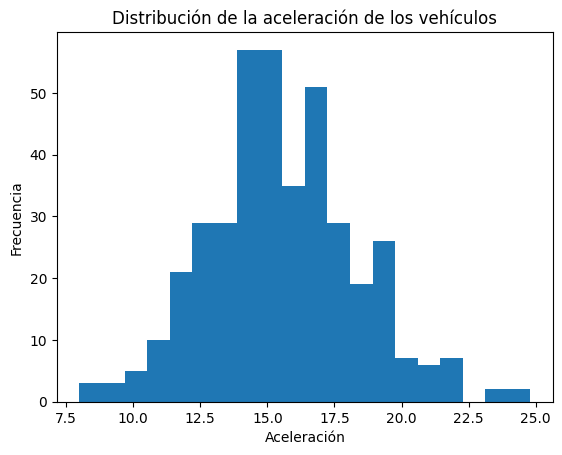

In [8]:
plt.hist(df['acceleration'], bins=20)

plt.title("Distribución de la aceleración de los vehículos")
plt.xlabel("Aceleración")
plt.ylabel("Frecuencia")

plt.show()

Grafica el Desplazamiento del motor (displacement) en el eje X versus los Caballos de fuerza (horsepower) en el eje Y.

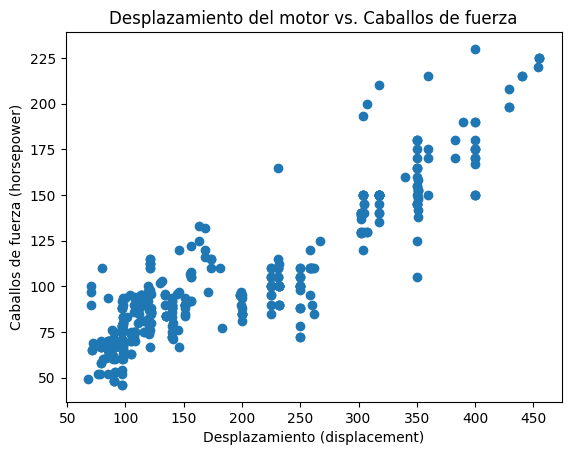

In [10]:
plt.scatter(df['displacement'], df['horsepower'])

plt.title("Desplazamiento del motor vs. Caballos de fuerza")
plt.xlabel("Desplazamiento (displacement)")
plt.ylabel("Caballos de fuerza (horsepower)")

plt.show()

Muestra el promedio de rendimiento (mpg - millas por galón) agrupado por el país de origen (origin).

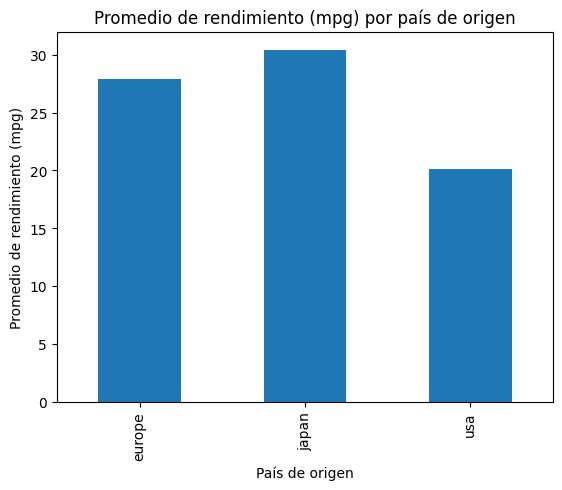

In [12]:
mpg_by_origin = df.groupby('origin')['mpg'].mean()
mpg_by_origin.plot(kind='bar')

plt.title("Promedio de rendimiento (mpg) por país de origen")
plt.xlabel("País de origen")
plt.ylabel("Promedio de rendimiento (mpg)")

plt.show()